In [40]:
import numpy as np
from astropy.io import ascii
import matplotlib.pyplot as plt
def grmonty(file):
    """
    Reads SEDs in the format provided by grmonty. Ported from 
    the original SM script `plspec.m` provided by J. Dolence.
    
    Returns:
        lognu: Logarithmic frequency values
        ll: Logarithmic luminosity values in shape (6, s['colx'].shape)
    """
    LSUN = 3.827e33
    CL = 2.99792458e10
    ME = 9.1093826e-28
    HPL =  6.6260693e-27
    # Read the file using ascii
    s = ascii.read(file, format='no_header')


    # Array conversions for luminosity values (log10)
    ll = np.zeros((6, len(s)))  # Pre-allocate the array with shape (6, s['colx'].shape)
    ll[0] = np.array(s['col2'] * LSUN)
    ll[1] = np.array(s['col8'] * LSUN)
    ll[2] = np.array(s['col14']* LSUN)
    ll[3] = np.array(s['col20']* LSUN)
    ll[4] = np.array(s['col26']* LSUN)
    ll[5] = np.array(s['col32']* LSUN)

    # Compute log frequency (log(nu)) values
    nu = np.array(10**s['col1'] * (ME * CL**2/HPL))
    #print(nu)
    # Return log(nu) and ll array
    return nu, ll
nu, nuLnu = grmonty('../output/SANE')
#domega_array = np.array([1.610196e+00, 3.714269e+00, 3.703976e+00, 
                         #2.401148e+00, 9.885099e-01, 1.482720e-01])

In [41]:
import numpy as np
from astropy.io import ascii
import matplotlib.pyplot as plt
def grmonty(file):
    """
    Reads SEDs in the format provided by grmonty. Ported from 
    the original SM script `plspec.m` provided by J. Dolence.
    
    Returns:
        lognu: Logarithmic frequency values
        ll: Logarithmic luminosity values in shape (6, s['colx'].shape)
    """
    LSUN = 3.827e33
    CL = 2.99792458e10
    ME = 9.1093826e-28
    HPL =  6.6260693e-27
    # Read the file using ascii
    s = ascii.read(file, format='no_header')


    # Array conversions for luminosity values (log10)
    ll = np.zeros((6, len(s)))  # Pre-allocate the array with shape (6, s['colx'].shape)
    ll[0] = np.array(s['col2'] * LSUN)
    ll[1] = np.array(s['col8'] * LSUN)
    ll[2] = np.array(s['col14']* LSUN)
    ll[3] = np.array(s['col20']* LSUN)
    ll[4] = np.array(s['col26']* LSUN)
    ll[5] = np.array(s['col32']* LSUN)

    # Compute log frequency (log(nu)) values
    nu = np.array(10**s['col1'] * (ME * CL**2/HPL))
    #print(nu)
    # Return log(nu) and ll array
    return nu, ll
nu_gr, nuLnu_gr = grmonty('../../new/grmonty/output/file1.spec')
#domega_array = np.array([1.610196e+00, 3.714269e+00, 3.703976e+00, 
                         #2.401148e+00, 9.885099e-01, 1.482720e-01])

Text(0.5, 1.0, 'GPUmonty averaged 20 runs')

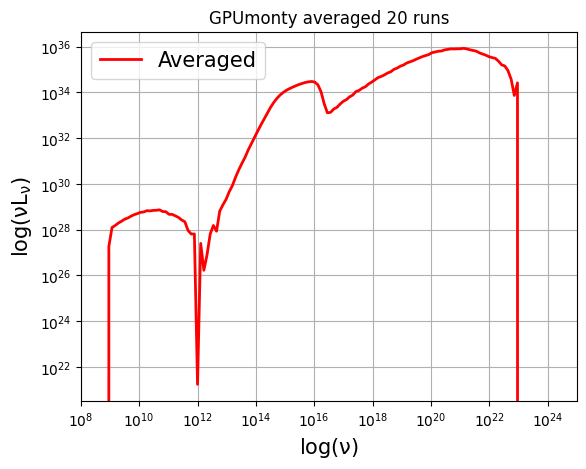

In [43]:
#from gpumonty
import nmmn.sed
import matplotlib.pyplot as plt
import numpy as np
number_of_outputs = 20
plt.grid(True)

plt.ylabel(r'$\rm log(\nu L_\nu)$', fontsize = 15)
plt.xlabel(r'$\rm log(\nu)$', fontsize = 15)

plt.plot(nu, nuLnu[5], lw = 2, color = 'red', label = 'Averaged')
#plt.plot(nu_gr, nuLnu_gr[5], lw = 2, linestyle = '--', color = 'blue', label = 'Averaged')

plt.yscale('log')
plt.xscale('log')
plt.xlim(1e8, 1e25)
plt.legend(fontsize = 15)
plt.title("GPUmonty averaged 20 runs")


In [109]:
num_runs = 3
nu = np.zeros((num_runs+1, 200))        # Shape (20, 200)
nuLnu = np.zeros((num_runs+1, 6, 200))  # Shape (20, 5, 200)
num_runs_grmonty = 3
nu_gr = np.zeros((num_runs_grmonty+1, 200))        # Shape (20, 200)
nuLnu_gr = np.zeros((num_runs_grmonty+1, 6, 200))  # Shape (20, 5, 200)

# Loop through the specified range and call grmonty
for i in range(1, num_runs + 1):
    nu[i], nuLnu[i] = grmonty(f'../output/SANE_{i}.spec')

for i in range(1, num_runs_grmonty + 1):
    nu_gr[i], nuLnu_gr[i] = grmonty(f'../../new/grmonty/output/SANE_{i}.spec')



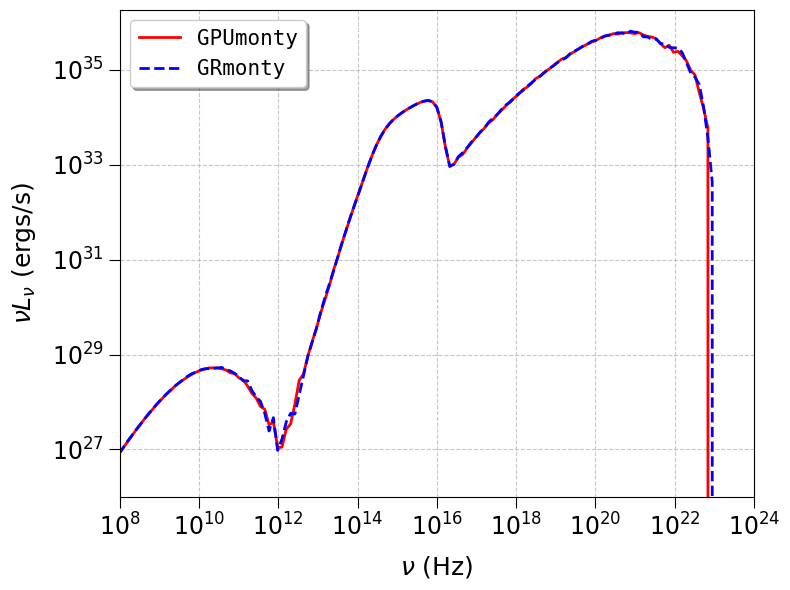

In [113]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.figure(figsize=(8, 6))

# Define axis labels with larger fonts and improved readability
plt.ylabel(r'$\nu L_\nu$ (ergs/s)', fontsize=18, labelpad=10)
plt.xlabel(r'$\nu$ (Hz)', fontsize=18, labelpad=10)

# Define a color map for different inclinations
i = 4
colors = ['blue', 'green', 'orange', 'purple', 'red']
inclinations = ['0°', '45°', '90°', '135°', '180°']

# Solid line for `nuLnu` (GPUmonty)
plt.plot(nu.mean(0), nuLnu.mean(0)[5], lw=2, color=colors[i],label = 'GPUmonty')

# Dashed line for `nuLnu_2` (GRmonty)
plt.plot(nu_gr.mean(0), nuLnu_gr.mean(0)[5], lw=2, color='blue', linestyle='--', label = 'GRmonty')

# Set logarithmic scale for axes
plt.yscale('log')
plt.xscale('log')

# Define axis limits
plt.ylim(1e26, None)
plt.xlim(1e8, 1e24)

# Place the legend on the right side
plt.legend(loc='best', frameon=True, shadow=True, prop={'family': 'monospace', 'size': 15})


# Enable grid with a lighter color
plt.grid(True, which='both', linestyle='--', alpha=0.7)
        
# Increase tick size
plt.tick_params(axis='both', which='major', labelsize=17, length=8)
plt.tick_params(axis='both', which='minor', labelsize=12, length=5)

# Display the plot
plt.tight_layout()
#plt.savefig('SANE_averaged.pdf', bbox_inches='tight', dpi=300)
plt.show()


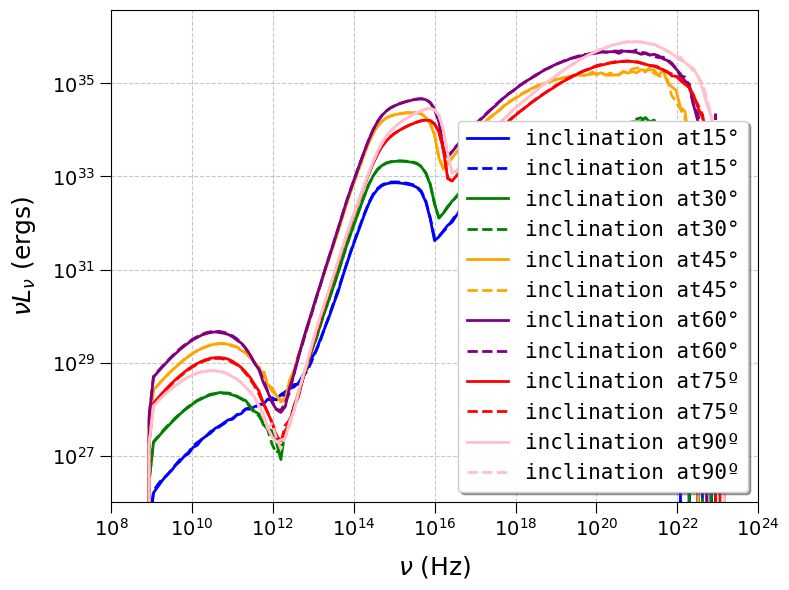

In [89]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.figure(figsize=(8, 6))

# Define axis labels with larger fonts and improved readability
plt.ylabel(r'$\nu L_\nu$ (ergs)', fontsize=18, labelpad=10)
plt.xlabel(r'$\nu$ (Hz)', fontsize=18, labelpad=10)

# Define a color map for different inclinations
i = 4
colors = ['blue', 'green', 'orange', 'purple', 'red', 'pink']
inclinations = ['15°', '30°', '45°', '60°', '75º', '90º']

# Solid line for `nuLnu` (GPUmonty)
for i in range(6):
    plt.plot(nu.mean(0), nuLnu.mean(0)[i], lw=2, color=colors[i],label = 'inclination at'+str(inclinations[i]))
    # Dashed line for `nuLnu_2` (GRmonty)
    plt.plot(nu_gr.mean(0), nuLnu_gr.mean(0)[i], lw=2, color=colors[i], linestyle='--', label = 'inclination at'+str(inclinations[i]))

# Set logarithmic scale for axes
plt.yscale('log')
plt.xscale('log')

# Define axis limits
plt.ylim(1e26, None)
plt.xlim(1e8, 1e24)

# Place the legend on the right side
plt.legend(loc='best', frameon=True, shadow=True, prop={'family': 'monospace', 'size': 15})


# Enable grid with a lighter color
plt.grid(True, which='both', linestyle='--', alpha=0.7)
        
# Increase tick size
plt.tick_params(axis='both', which='major', labelsize=14, length=8)
plt.tick_params(axis='both', which='minor', labelsize=12, length=5)

# Display the plot
plt.tight_layout()
#plt.savefig('SANE_averaged.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [624]:
import struct
#Load data
#Loop through every cell
# Specify the binary file name
file_name = '../../../gpumonty/data/MAD_0.9_new.bin'

import numpy as np

flatten_x1 = sim_init.x1[0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_x2 = sim_init.x2[0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_x3 = sim_init.x3[0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_r = sim_init.r[0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_h = sim_init.h[0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_ph = sim_init.ph[0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_rho = sim_init.rho[0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_uu0 = sim_init.ug[0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_uu1 = sim_init.uu[1][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_uu2 = sim_init.uu[2][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_uu3 = sim_init.uu[3][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_B1 = sim_init.B[1,:,:,:][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_B2 = sim_init.B[2,:,:,:][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_B3 = sim_init.B[3,:,:,:][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_ud0 = sim_init.ud[0][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_ud1 = sim_init.ud[1][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_ud2 = sim_init.ud[2][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_ud3 = sim_init.ud[3][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_bu0 = sim_init.bu[0][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_bu1 = sim_init.bu[1][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_bu2 = sim_init.bu[2][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_bu3 = sim_init.bu[3][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_bd0 = sim_init.bd[0][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_bd1 = sim_init.bd[1][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_bd2 = sim_init.bd[2][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
flatten_bd3 = sim_init.bd[3][0,:,:,sim_init.bs3new//2].flatten().astype(np.float64)
gdet_modified = sim_init.gdet.flatten().astype(np.float64)
print(gdet_modified.shape)
print(sim_init.gdet.shape)
#flatten_gdet = sim_init.gdet[0,:,:,0].flatten().astype(np.float64)


# Save arrays to a binary file in order
with open(file_name, 'wb') as f:
    f.write(sim_init.t.tobytes())
    f.write(struct.pack('i', sim_init.bs1new))
    f.write(struct.pack('i', sim_init.bs2new))
    f.write(struct.pack('i', sim_init.bs3new))
    f.write(sim_init.startx1.tobytes())
    f.write(sim_init.startx2.tobytes())
    f.write(sim_init.startx3.tobytes())
    f.write(sim_init._dx1.tobytes())
    f.write(sim_init._dx2.tobytes())
    f.write(sim_init._dx3.tobytes())
    f.write(sim_init.a.tobytes())
    f.write(sim_init.gam.tobytes())
    #For 2d bs3new = 1
    for k in tqdm.tqdm(range(sim_init.bs1new * sim_init.bs2new * 1)):
        f.write(flatten_x1[k].tobytes())
        f.write(flatten_x2[k].tobytes())
        #f.write(flatten_x3[k].tobytes())
        f.write(flatten_r[k].tobytes())
        f.write(flatten_h[k].tobytes())
        #f.write(flatten_ph[k].tobytes())        
        f.write(flatten_rho[k].tobytes())
        f.write(flatten_uu0[k].tobytes())
        f.write(flatten_uu1[k].tobytes())        
        f.write(flatten_uu2[k].tobytes())
        f.write(flatten_uu3[k].tobytes())
        f.write(flatten_B1[k].tobytes())
        f.write(flatten_B2[k].tobytes())
        f.write(flatten_B3[k].tobytes())
        f.write(flatten_uu0[k].tobytes())
        f.write(flatten_uu1[k].tobytes())        
        f.write(flatten_uu2[k].tobytes())
        f.write(flatten_uu3[k].tobytes())
        f.write(flatten_ud0[k].tobytes())        
        f.write(flatten_ud1[k].tobytes())
        f.write(flatten_ud2[k].tobytes())
        f.write(flatten_ud3[k].tobytes())
        f.write(flatten_bu0[k].tobytes())
        f.write(flatten_bu1[k].tobytes())
        f.write(flatten_bu2[k].tobytes())
        f.write(flatten_bu3[k].tobytes())
        f.write(flatten_bd0[k].tobytes())
        f.write(flatten_bd1[k].tobytes())
        f.write(flatten_bd2[k].tobytes())
        f.write(flatten_bd3[k].tobytes())
        f.write(gdet_modified[k].tobytes())


#I was using /home/pedro/macros/macros_hamr/my_macros


KeyboardInterrupt



ValueError: x and y must have same first dimension, but have shapes (21, 200) and (6, 200)

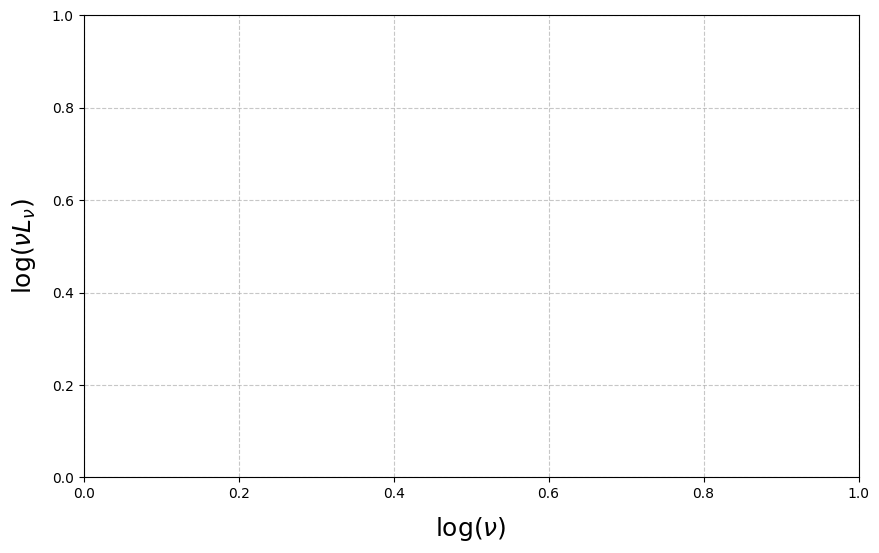

In [81]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Enable grid with a lighter color
plt.grid(True, linestyle='--', alpha=0.7)

# Define axis labels with larger fonts and improved readability
plt.ylabel(r'$\mathrm{log}(\nu L_\nu)$', fontsize=18, labelpad=10)
plt.xlabel(r'$\mathrm{log}(\nu)$', fontsize=18, labelpad=10)

# Define a color map for different inclinations
colors = ['blue', 'green', 'orange', 'purple', 'red']
inclinations = ['0°', '45°', '90°', '135°', '180°']

# Plot each inclination with varied colors and distinct styles
for i in range(5):
    # Solid line for `nuLnu` (GPUmonty)
    plt.plot(nu, nuLnu[i], lw=1, color=colors[i])
    
    # Dashed line for `nuLnu_2` (GRmonty)
    plt.plot(nu2, nuLnu_2[i], lw=1, color=colors[i], linestyle='--')

# Set logarithmic scale for axes
plt.yscale('log')
plt.xscale('log')

# Define axis limits
plt.ylim(1e18, None)
plt.xlim(1e8, 1e23)

# Add title with slightly larger font
plt.title(r'Spectrum at Different Inclinations', fontsize=18, pad=15)

# Customize legend for color-inclination association
for i in range(5):
    plt.plot([], [], color=colors[i], label=f'Inclination {inclinations[i]}')

# Place the legend on the right side
plt.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, shadow=True)

# Create custom legend entries for line styles
custom_lines = [
    Line2D([0], [0], color='black', lw=1, linestyle='-', label='GPUmonty'),
    Line2D([0], [0], color='black', lw=1, linestyle='--', label='GRmonty')
]

# Add the first legend for inclinations
plt.legend(fontsize=12, loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, shadow=True)

# Add the custom legend below the plot for line types
plt.figlegend(handles=custom_lines, fontsize=12, loc='lower center', bbox_to_anchor=(0.45, -0.05), frameon=True, shadow=True, ncol=2)

# Display the plot
plt.tight_layout()
plt.show()



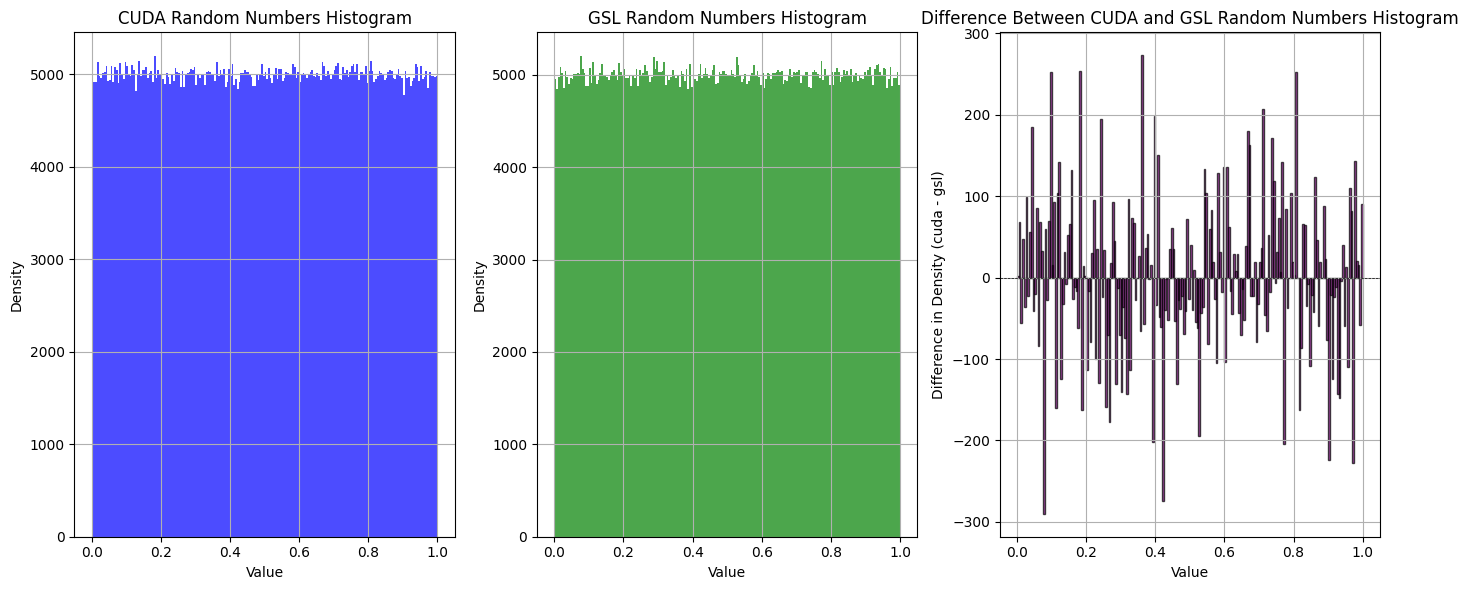

In [291]:
import numpy as np
import matplotlib.pyplot as plt

# Function to read binary data from a file
def read_random_numbers(file_path):
    with open(file_path, 'rb') as f:
        random_numbers = np.fromfile(f, dtype=np.float64)  # Assuming double precision (64 bits)
    return random_numbers

# File paths
cuda_file_path = './python/cuda_tests/cuda_random_numbers.bin'
gsl_file_path = './python/cuda_tests/gsl_random_numbers.bin'

# Read random numbers from files
cuda_random_numbers = read_random_numbers(cuda_file_path)
gsl_random_numbers = read_random_numbers(gsl_file_path)

# Create histograms
bins = np.linspace(0, 1, 201)  # Define bins for histograms (0 to 1 with 200 bins)
cuda_hist, _ = np.histogram(cuda_random_numbers, bins=bins, density=False)
gsl_hist, _ = np.histogram(gsl_random_numbers, bins=bins, density=False)

# Calculate the difference in histogram values
diff_hist = cuda_hist - gsl_hist

# Plot histograms and their difference
plt.figure(figsize=(14, 6))

# CUDA random numbers histogram
plt.subplot(1, 3, 1)
plt.hist(cuda_random_numbers, bins=bins, color='blue', alpha=0.7, density=False)
plt.title('CUDA Random Numbers Histogram')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(True)

# GSL random numbers histogram
plt.subplot(1, 3, 2)
plt.hist(gsl_random_numbers, bins=bins, color='green', alpha=0.7, density=False)
plt.title('GSL Random Numbers Histogram')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(True)

# Difference histogram
plt.subplot(1, 3, 3)
plt.bar(bins[:-1], diff_hist, width=np.diff(bins), color='purple', alpha=0.7, align='edge', edgecolor='black')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')  # Line at y=0 for reference
plt.title('Difference Between CUDA and GSL Random Numbers Histogram')
plt.xlabel('Value')
plt.ylabel('Difference in Density (cuda - gsl)')
plt.grid(True)

# Show the plots
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'GRmonty and GPUmonty averaged 20 runs')

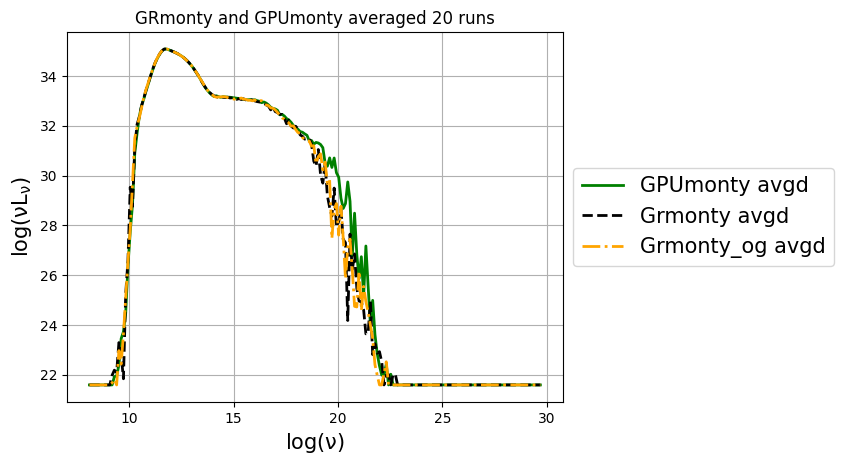

In [24]:
#from gpumonty
import nmmn.sed
import matplotlib.pyplot as plt
import numpy as np
number_of_outputs = 20
plt.grid(True)
ydata = np.zeros((number_of_outputs, 200))
xdata = np.zeros((number_of_outputs, 200))
plt.ylabel(r'$\rm log(\nu L_\nu)$', fontsize = 15)
plt.xlabel(r'$\rm log(\nu)$', fontsize = 15)
s=nmmn.sed.SED()
cmap = plt.get_cmap('CMRmap')
for i in range(number_of_outputs):
    s.grmonty('/home/pedro/grmonty/output/grmonty_'+str(i))
    xdata[i] = s.lognu
    ydata[i] = s.ll
#for i in range(number_of_outputs):
#    plt.plot(xdata.mean(0), ydata[i],'--', color=cmap(i / number_of_outputs))
plt.plot(xdata_gpu.mean(0), ydata_gpu.mean(0), lw = 2, color = 'green', label = 'GPUmonty avgd')
plt.plot(xdata.mean(0), ydata.mean(0), lw = 2, linestyle = '--', color = 'black', label = 'Grmonty avgd')
plt.plot(xdata_og.mean(0), ydata_og.mean(0), lw = 2, linestyle = '-.', color = 'orange', label = 'Grmonty_og avgd')

plt.legend(fontsize = 15,loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("GRmonty and GPUmonty averaged 20 runs")



Text(0.5, 1.0, 'GRmonty_og averaged 20 runs')

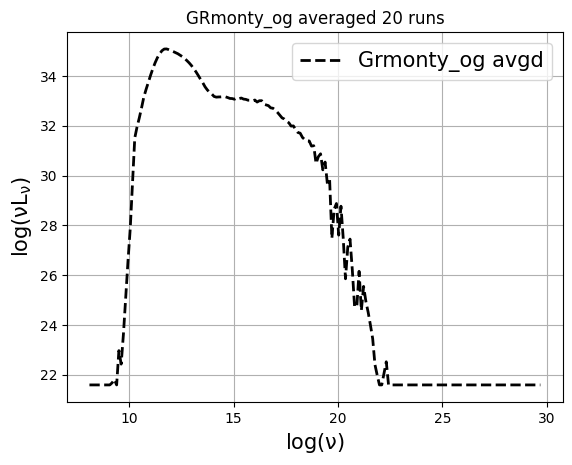

In [22]:
#from gpumonty
import nmmn.sed
import matplotlib.pyplot as plt
import numpy as np
number_of_outputs = 20
plt.grid(True)
ydata_og = np.zeros((number_of_outputs, 200))
xdata_og = np.zeros((number_of_outputs, 200))
plt.ylabel(r'$\rm log(\nu L_\nu)$', fontsize = 15)
plt.xlabel(r'$\rm log(\nu)$', fontsize = 15)
s=nmmn.sed.SED()
cmap = plt.get_cmap('CMRmap')
for i in range(number_of_outputs):
    s.grmonty('/home/pedro/grmonty_original/grmonty/output/grmonty_original_'+str(i))
    xdata_og[i] = s.lognu
    ydata_og[i] = s.ll
#for i in range(number_of_outputs):
#    plt.plot(xdata.mean(0), ydata[i],'--', color=cmap(i / number_of_outputs))
plt.plot(xdata_og.mean(0), ydata_og.mean(0), lw = 2, linestyle = '--', color = 'black', label = 'Grmonty_og avgd')
plt.legend(fontsize = 15)
plt.title("GRmonty_og averaged 20 runs")



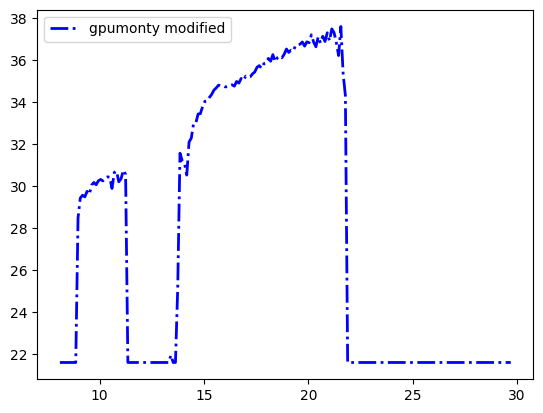

In [29]:
import nmmn.sed
import matplotlib.pyplot as plt
s=nmmn.sed.SED()
#s.grmonty('../grmonty_original/grmonty/output/grmonty.spec')
#plt.plot(s.lognu, s.ll, color = 'green', label = 'grmonty_og')
#s.grmonty('../grmonty/output/grmonty.spec')
#plt.plot(s.lognu, s.ll, '-.', color = 'red', label = 'grmonty modified')
s.grmonty('../gpumonty/output/grmonty.spec')
plt.plot(s.lognu, s.ll, '-.', color = 'blue', label = 'gpumonty modified', lw = 2)
plt.legend()
plt.show()


In [52]:
s = nmmn.sed.SED(file='./output/grmonty_hamr.spec', logfmt=0)

./output/grmonty_hamr.spec


/home/pedro/anaconda3/lib/python3.8/site-packages/nmmn/sed.py:82: RuntimeWarning: invalid value encountered in log10
  self.lognu, self.ll = numpy.log10(self.nu), numpy.log10(self.nlnu)
/home/pedro/anaconda3/lib/python3.8/site-packages/nmmn/sed.py:82: RuntimeWarning: divide by zero encountered in log10
  self.lognu, self.ll = numpy.log10(self.nu), numpy.log10(self.nlnu)


In [106]:
def read_nuLnu_from_spectrum_file(file_name):
    nuLnu_values = []
    with open(file_name, 'r') as file:
        for line in file:
            # Split the line into individual values using whitespace as delimiter
            values = line.split()
            # Check if the line contains values (not an empty line)
            if values:
                # Extract the nuLnu value from the line (it's the second value)
                nuLnu_value = float(values[1])
                nuLnu_values.append(nuLnu_value)
    return nuLnu_values

# Replace 'SPECTRUM_FILE_NAME' with the actual file path
nuLnu_values = read_nuLnu_from_spectrum_file(file_path)
print("nuLnu values:", nuLnu_values)




nuLnu values: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.9795e-08, 0.16294, 0.09554, 0.31237, 0.28136, 1.1907, 3.1314, 3.9721, 4.1646, 4.9079, 5.2369, 5.2806, 4.7781, 4.2869, 4.3989, 3.1199, 3.4294, 2.7722, 2.9593, 2.9633, 2.0972, 2.1567, 1.609, 1.403, 1.4743, 1.0098, 0.84451, 0.6848, 0.69932, 0.58085, 0.53495, 0.49773, 0.55971, 0.60763, 0.69177, 0.76297, 0.96119, 1.1109, 1.268, 1.4486, 1.7876, 1.7437, 2.0722, 2.3565, 2.7302, 3.1273, 3.0155, 2.7875, 2.402, 2.0906, 2.6469, 1.9522, 0.89921, 0.6548, 0.0049984, 0.001388, 0.0095959, 0.0089384, 0.0043158, 0.012617, 0.0091483, 0.0070273, 0.0091606, 0.0049205, 0.012333, 0.0091282, 0.02182, 0.0071606, 0.0032759, 0.0055243, 0.0049165, 0.0, 0.010323, 1.8265e-06, 0.0039933, 0.00058114, 0.0075088, 0.00457, 0.0047716, 0.0023739, 0.0, 0.00055013, 0.013843, 0.0016391, 0.00030738, 0.0, 0.001354, 0.013526, 0.0098384, 0.0044875, 0.0023641, 0.004816, 0.0, 0.0014234, 4.0709e-05, 0.0, 0.0, 0.0

In [194]:
array = []
with open('./output/grmonty_hamr.spec', 'r') as file:
    for line in file:
        # Split the line into individual values using whitespace as delimiter
        values = line.split()
        # Extend the array list with the values obtained from the line
        array.extend(values)


In [192]:
array = []
with open('../grmonty/output/grmonty_hamr.spec', 'r') as file:
    for line in file:
        # Split the line into individual values using whitespace as delimiter
        values = line.split()
        # Extend the array list with the values obtained from the line
        array.extend(values)

In [219]:
array_queimporta_hamr =[]

index = 0
for i in range(200):
    index +=1
    for j in range(6):
        array_queimporta_hamr.append(float(array[index]))
        if (float(array[index]) == 141.95):
            print("i = ", i, "j = ", j)
        index += 6


i =  18 j =  5


In [218]:
print(array_queimporta_hamr[113])
print(array_queimporta[113])

141.95
1153.2


In [216]:
results = []
old_index = 0
mar_var = 0
for i in range(1200):
    value = array_queimporta_hamr[i] - array_queimporta[i]
    #print("i =", i, "difference = ", value)
    if(abs(value) > max_var):
        index_max = i
        max_var = abs(value)
print("i =", index_max, "difference = ", max_var)
    #results.append(value)

i = 113 difference =  1011.25


In [78]:
import numpy as np
def read_float_array_from_file(filename):
    float_array = []
    with open(filename, 'r') as file:
        for line in file:
            # Convert each line to float and append to the array
            float_array.append(float(line.strip()))
    return float_array

def compare_arrays(arr1, arr2):
    # if len(arr1) != len(arr2):
        # print("len of both arrays don't match")
        # return False
    
    for i in range(len(arr2)):
        if arr1[i] != arr2[i]:
            print("does not match at i =", i)
            #return False
    return True

# Replace 'file1.txt' and 'file2.txt' with your file paths
file1_array = np.array(read_float_array_from_file('../grmonty_3D/output_nz.txt'))
file2_array = np.array(read_float_array_from_file('../gpumonty/output_nz.txt'))

if compare_arrays(file1_array, file2_array):
    print("Arrays match at every index.")
else:
    print("Arrays do not match at every index.")


Arrays match at every index.


In [76]:
print(file1_array[82])
print(file2_array[82])

81.0
80.0


In [39]:
#file1_array[0]
file2_array[0]

93.0

In [33]:
256 * 256

65536

In [81]:
help(nmmn.sed)

Help on module nmmn.sed in nmmn:

NAME
    nmmn.sed

DESCRIPTION
    Spectral energy distributions
    
    Methods and classes for dealing with spectral energy distributions (SEDs).

CLASSES
    builtins.object
        SED
    
    class SED(builtins.object)
     |  SED(file=None, logfmt=0, lognu=None, ll=None)
     |  
     |  Class that defines objects storing Spectral energy distributions (SEDs). 
     |  The SEDs can be imported either from datafiles with the observations/models,
     |  or from arrays with the values of log(nu) and log(nuLnu).
     |  
     |  The object's initial attributes are:
     |  
     |  - nu: frequency in Hertz
     |  - lognu: log10(frequency)
     |  - nlnu: nu L_nu in erg/s
     |  - ll: log10(nu Lnu)
     |  - file : input datafile
     |  
     |  To import a SED from an ASCII file:
     |  
     |  >>> s=sed.SED(file=datafile, logfmt=XX)
     |  
     |  where logfmt is 1 if the data is already in logarithm or 0 otherwise.
     |  NOTE: logfmt for

In [186]:
import re

# Regular expression to match lines containing "a = [integer]"
pattern =re.compile(r'test\[(\d+)\] = (\d+\.\d+e[+-]\d+)')

# Array to store integer values
integer_values = []
values = []

# Read the file line by line
with open('output.txt', 'r') as file:
    for line in file:
        # Search for pattern in line
        match = pattern.search(line)
        if match:
            # Extract integer value and store it in the array
            integer_values.append(int(match.group(1)))
            values.append(float(match.group(2)))

# Print the array of integer values
#print("Integer values:", integer_values)
print(len(values))
print(len(integer_values))

16709
16709


In [222]:
import re

# Initialize lists to store data
test_indexes = []
test_values = []
scat_indexes = []
scat_values = []

# Read the data from the text file
with open('output.txt', 'r') as file:
    data = file.read()

# Regular expression patterns to match the data format
test_pattern = re.compile(r'test\[(\d+)\]\s*=\s*([\d.e+-]+)')
scat_pattern = re.compile(r'scat_ofphoton\[(\d+)\]\s*=\s*([\d.e+-]+)')

# Parse the data using regular expressions
for index, value in test_pattern.findall(data):
    test_indexes.append(int(index))
    test_values.append(float(value))

for index, value in scat_pattern.findall(data):
    scat_indexes.append(int(index))
    scat_values.append(float(value))


In [220]:
# Count occurrences of each scat index
scat_index_counts = {}
for index in scat_indexes:
    scat_index_counts[index] = scat_index_counts.get(index, 0) + 1

# Count the total number of repeating occurrences
total_repeating_occurrences = sum(count - 1 for count in scat_index_counts.values() if count > 1)

# Print the total number of repeating occurrences
print("Total number of repeating occurrences:", total_repeating_occurrences)


Total number of repeating occurrences: 1677


In [223]:
# Count occurrences of each scat index
scat_index_counts = {}
for index in scat_indexes:
    scat_index_counts[index] = scat_index_counts.get(index, 0) + 1

# Print number of occurrences for each duplicate scat index
print("Number of occurrences for each duplicate scat index:")
for index, count in scat_index_counts.items():
    if count > 1:
        print("Scat index", index, "has", count, "occurrences")


Number of occurrences for each duplicate scat index:
Scat index 469235 has 2 occurrences
Scat index 469800 has 2 occurrences
Scat index 469662 has 2 occurrences
Scat index 468787 has 3 occurrences
Scat index 470216 has 3 occurrences
Scat index 470342 has 2 occurrences
Scat index 470492 has 2 occurrences
Scat index 470877 has 2 occurrences
Scat index 470510 has 2 occurrences
Scat index 472362 has 2 occurrences
Scat index 469849 has 2 occurrences
Scat index 472783 has 2 occurrences
Scat index 470812 has 2 occurrences
Scat index 470371 has 2 occurrences
Scat index 470149 has 2 occurrences
Scat index 469042 has 2 occurrences
Scat index 471734 has 2 occurrences
Scat index 470864 has 2 occurrences
Scat index 469667 has 2 occurrences
Scat index 471573 has 2 occurrences
Scat index 472086 has 2 occurrences
Scat index 470407 has 2 occurrences
Scat index 468634 has 2 occurrences
Scat index 472443 has 2 occurrences
Scat index 472556 has 2 occurrences
Scat index 466018 has 2 occurrences
Scat index 

In [187]:
import re

# Define regular expressions to extract values within brackets
ph_regex = re.compile(r'ph\[(\d+)\] = (\d+\.\d+e[+-]\d+)')
#scat_regex = re.compile(r'scat_ofphoton\[(\d+)\] = (\d+\.\d+e[+-]\d+)')

# Arrays to store indexes
ph_indexes = []
ph_values = []
scat_indexes = []
scat_values = []

# Read the file line by line
with open('output.txt', 'r') as file:
    for line in file:
        # Match ph values
        match_ph = ph_regex.search(line)
        if match_ph:
            ph_indexes.append(int(match_ph.group(1)))
            ph_values.append(float(match_ph.group(2)))

        # Match scat_ofphoton values
        match_scat = scat_regex.search(line)
        if match_scat:
            scat_indexes.append(int(match_scat.group(1)))
            scat_values.append(float(match_scat.group(2)))

# Print arrays
#print("ph indexes:", ph_indexes)
#print("ph values:", ph_values)
#print("scat_ofphoton indexes:", scat_indexes)
#print("scat_ofphoton values:", scat_values)
print(len(ph_indexes))
print(len(scat_indexes))

0
0


In [189]:
import re

# Initialize arrays to store values
ph_indexes = []
test_indexes = []
test_values = []

# Regular expressions to match lines containing ph_index and test values
ph_regex = re.compile(r'ph_index\s*=\s*(\d+)')
test_regex = re.compile(r'test\[(\d+)\]\s*=\s*([\d.e+-]+)')

# Read the file line by line
with open('output.txt', 'r') as file:
    for line in file:
        # Match ph_index
        match_ph = ph_regex.match(line)
        if match_ph:
            ph_indexes.append(int(match_ph.group(1)))
        
        # Match test values
        match_test = test_regex.match(line)
        if match_test:
            test_indexes.append(int(match_test.group(1)))
            test_values.append(float(match_test.group(2)))

# Compare test_indexes with ph_indexes
different_indices = set(test_indexes) - set(ph_indexes)

# Find repeated numbers in ph_indexes and test_indexes
repeated_ph_indexes = [item for item in ph_indexes if ph_indexes.count(item) > 1]
repeated_test_indexes = [item for item in test_indexes if test_indexes.count(item) > 1]

# Print the results
#print("ph_indexes:", ph_indexes)
#print("test_indexes:", test_indexes)
#print("test_values:", test_values)
print("Different indices between test_indexes and ph_indexes:", len(different_indices))
print("Repeated numbers in ph_indexes:",  len(repeated_ph_indexes))
print("Repeated numbers in test_indexes:",  len(repeated_test_indexes))


Different indices between test_indexes and ph_indexes: 0
Repeated numbers in ph_indexes: 3164
Repeated numbers in test_indexes: 0


In [200]:
flag = False
for j in range(len(test_indexes)):
    for i in range(len(ph_indexes)):
        if(ph_indexes[i] == test_indexes[j]):
            if (flag == True):
                pass
                print("Repeated index at index:", ph_indexes[i])
            flag = True
    if (flag == True):
        flag = False
    else:
        print("index:", test_indexes[j], "Does not correspond in ph")

Repeated index at index: 465679
Repeated index at index: 466018
Repeated index at index: 466560
Repeated index at index: 466560
Repeated index at index: 466798
Repeated index at index: 466833
Repeated index at index: 466833
Repeated index at index: 467087
Repeated index at index: 467113
Repeated index at index: 467343
Repeated index at index: 467388
Repeated index at index: 467389
Repeated index at index: 467621
Repeated index at index: 467621
Repeated index at index: 467656
Repeated index at index: 467782
Repeated index at index: 467816
Repeated index at index: 467870
Repeated index at index: 467872
Repeated index at index: 467872
Repeated index at index: 468075
Repeated index at index: 468094
Repeated index at index: 468144
Repeated index at index: 468150
Repeated index at index: 468394
Repeated index at index: 468457
Repeated index at index: 468538
Repeated index at index: 468634
Repeated index at index: 468787
Repeated index at index: 468787
Repeated index at index: 468898
Repeated

KeyboardInterrupt: 

In [132]:
flag = False
for j in range(len(ph_indexes)):
    for i in range(len(scat_indexes)):
        if(ph_indexes[j] == scat_indexes[i]):
            if (flag == True):
                print("Repeated index at index:", ph_indexes[j])
            flag = True
    if (flag == True):
        flag = False
    else:
        print("index:", scat_indexes[i], "Does not correspond in ph")

Repeated index at index: 465520
Repeated index at index: 465553
Repeated index at index: 465951
Repeated index at index: 466084
Repeated index at index: 466303
Repeated index at index: 466355
Repeated index at index: 468702
Repeated index at index: 468702
Repeated index at index: 468797
Repeated index at index: 468883
Repeated index at index: 468890
Repeated index at index: 468999
Repeated index at index: 469084
Repeated index at index: 469115
Repeated index at index: 469267
Repeated index at index: 469274
Repeated index at index: 469315
Repeated index at index: 469358
Repeated index at index: 469461
Repeated index at index: 469461
Repeated index at index: 469461
Repeated index at index: 469480
Repeated index at index: 469531
Repeated index at index: 469538
Repeated index at index: 469538
Repeated index at index: 469635
Repeated index at index: 469677
Repeated index at index: 469856
Repeated index at index: 469948
Repeated index at index: 470514
Repeated index at index: 471297
Repeated

KeyboardInterrupt: 